 **---------------------------------------------Text Generation - Character-Level Prediction-------------------------------------------------------**


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Loading Data

In [ ]:
with open('/content/tiny shakespeare.txt', 'r') as file:
  data = file.read()

In [ ]:
data

"First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for the gods know I\nspeak this in hunger 

Cleaning Data

In [ ]:
import re

def clean_shakespeare_text(text: str) -> str:
    """
    Cleans Tiny Shakespeare text for character-level modeling.
    - Lowercases text
    - Replaces newlines with spaces
    - Removes extra spaces
    """
    # Lowercase
    text = text.lower()

    # Replace newlines & tabs with a space
    text = text.replace('\n', ' ').replace('\t', ' ')

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # Trim leading/trailing spaces
    text = text.strip()

    return text


In [ ]:
clean_data = clean_shakespeare_text(data)

In [ ]:
for sentence in clean_data.split('\n'):
  print(sentence)

first citizen: before we proceed any further, hear me speak. all: speak, speak. first citizen: you are all resolved rather to die than to famish? all: resolved. resolved. first citizen: first, you know caius marcius is chief enemy to the people. all: we know't, we know't. first citizen: let us kill him, and we'll have corn at our own price. is't a verdict? all: no more talking on't; let it be done: away, away! second citizen: one word, good citizens. first citizen: we are accounted poor citizens, the patricians good. what authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are too dear: the leanness that afflicts us, the object of our misery, is as an inventory to particularise their abundance; our sufferance is a gain to them let us revenge this with our pikes, ere we become rakes: for the gods know i speak this in hunger for bread, not in thirst for revenge. second cit

Mapping Characters to Indexes and Indexes to Characters.

In [ ]:
# Create toy dataset: "abcde"
# We'll train the RNN to predict: a->b, b->c, c->d, d->e
# data = "abcde"
chars = sorted(list(set(clean_data)))  # Sorting for consistent order
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")

# Mapping dicts
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Prepare training sequences
inputs  = [char_to_idx[ch] for ch in clean_data[:-1]]
targets = [char_to_idx[ch] for ch in clean_data[1:]]

print("Example mapping:")
print("Inputs: ", [idx_to_char[i] for i in inputs[:50]])
print("Targets:", [idx_to_char[i] for i in targets[:50]])







Vocabulary size: 38
Example mapping:
Inputs:  ['f', 'i', 'r', 's', 't', ' ', 'c', 'i', 't', 'i', 'z', 'e', 'n', ':', ' ', 'b', 'e', 'f', 'o', 'r', 'e', ' ', 'w', 'e', ' ', 'p', 'r', 'o', 'c', 'e', 'e', 'd', ' ', 'a', 'n', 'y', ' ', 'f', 'u', 'r', 't', 'h', 'e', 'r', ',', ' ', 'h', 'e', 'a', 'r']
Targets: ['i', 'r', 's', 't', ' ', 'c', 'i', 't', 'i', 'z', 'e', 'n', ':', ' ', 'b', 'e', 'f', 'o', 'r', 'e', ' ', 'w', 'e', ' ', 'p', 'r', 'o', 'c', 'e', 'e', 'd', ' ', 'a', 'n', 'y', ' ', 'f', 'u', 'r', 't', 'h', 'e', 'r', ',', ' ', 'h', 'e', 'a', 'r', ' ']


In [ ]:
print("Inputs:", inputs[:50])


Inputs: [17, 20, 29, 30, 31, 0, 14, 20, 31, 20, 37, 16, 25, 9, 0, 13, 16, 17, 26, 29, 16, 0, 34, 16, 0, 27, 29, 26, 14, 16, 16, 15, 0, 12, 25, 36, 0, 17, 32, 29, 31, 19, 16, 29, 5, 0, 19, 16, 12, 29]


Creating sequences for training the model

In [ ]:
import numpy as np
import tensorflow as tf

# Convert to numpy arrays
x = np.array(inputs)
y = np.array(targets)

seq_length = 100  # number of chars in each training sequence

def create_sequences(x, y, seq_length):
    sequences = []
    targets = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        targets.append(y[i:i+seq_length])
    return np.array(sequences), np.array(targets)

x_seq, y_seq = create_sequences(x, y, seq_length)

print(x_seq.shape, y_seq.shape)  # (num_sequences, seq_length)


(1108051, 100) (1108051, 100)


In [ ]:
x_seq[0]

array([17, 20, 29, 30, 31,  0, 14, 20, 31, 20, 37, 16, 25,  9,  0, 13, 16,
       17, 26, 29, 16,  0, 34, 16,  0, 27, 29, 26, 14, 16, 16, 15,  0, 12,
       25, 36,  0, 17, 32, 29, 31, 19, 16, 29,  5,  0, 19, 16, 12, 29,  0,
       24, 16,  0, 30, 27, 16, 12, 22,  7,  0, 12, 23, 23,  9,  0, 30, 27,
       16, 12, 22,  5,  0, 30, 27, 16, 12, 22,  7,  0, 17, 20, 29, 30, 31,
        0, 14, 20, 31, 20, 37, 16, 25,  9,  0, 36, 26, 32,  0, 12])

Defining Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,SimpleRNN

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(seq_length,)),
    # SimpleRNN(128,return_sequences=True),
    LSTM(256, return_sequences=True),  # keep outputs for each timestep

    Dense(vocab_size, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 64)        │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100, 38)        │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340,902 (1.30 MB)

 Trainable params: 340,902 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

Training the Model

In [ ]:
# history = model.fit(
#     x_seq, y_seq,
#     batch_size=64,
#     epochs=10
# )



history = model.fit(x_seq[:50000], y_seq[:50000], batch_size=256, epochs=50)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2553 - loss: 2.7231
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4608 - loss: 1.8271
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5459 - loss: 1.5161
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6093 - loss: 1.2896
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6789 - loss: 1.0737
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7490 - loss: 0.8693
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8100 - loss: 0.6989
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8583 - loss: 0.5638
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8924 - loss: 0.4625
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9156 - loss: 0.3864
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9292 - loss: 0.3319
Epoch 12/50
196/196 ━━━━━━━━━━━━━━━━━━

Plotting training loss over epochs

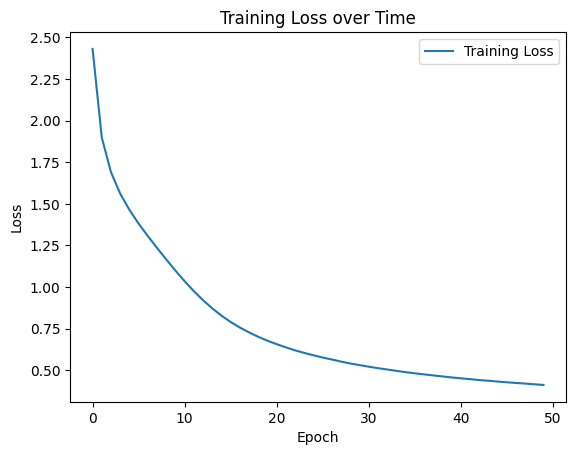

In [ ]:
import matplotlib.pyplot as plt

# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.show()


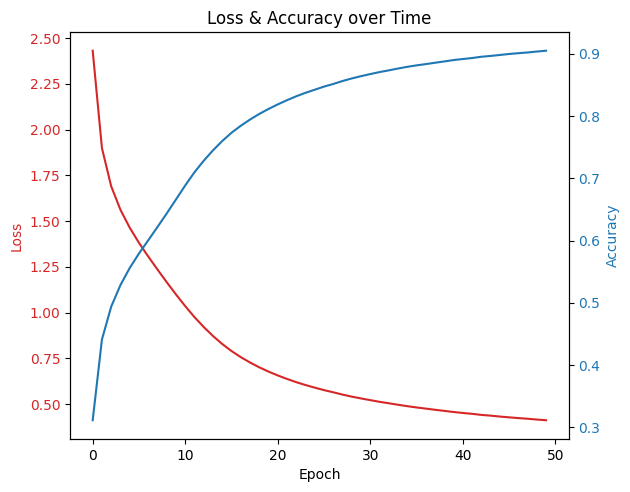

In [ ]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history.history['loss'], color='tab:red', label='Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(history.history['accuracy'], color='tab:blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.title('Loss & Accuracy over Time')
plt.show()


Inferencing using the trained model

In [ ]:

def generate_text(model, start_text, char_to_idx, idx_to_char, gen_length=300):
    # Prepare the input
    input_eval = [char_to_idx[c] for c in start_text.lower()]
    input_eval = np.expand_dims(input_eval, 0)  # shape (1, seq_length)

    text_generated = list(start_text)

    for _ in range(gen_length):
        predictions = model.predict(input_eval, verbose=0)

        # Get the prediction from the last timestep
        predicted_id = np.argmax(predictions[0, -1, :])

        # Append predicted char
        text_generated.append(idx_to_char[predicted_id])

        # Slide window by 1 character
        input_eval = np.append(input_eval[:, 1:], [[predicted_id]], axis=1)

    return ''.join(text_generated)


In [ ]:
print(generate_text(model, "I need not be barren of accusations", char_to_idx, idx_to_char, gen_length=50))


I need not be barren of accusations; he hath faults, with surplus, to tire in repetit


In [ ]:


def sample_with_temperature(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype('float64')
    predictions = np.log(predictions + 1e-8) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(predictions), p=predictions)

def generate_text_temp(model, start_text, char_to_idx, idx_to_char, gen_length=300, temperature=0.7):
    input_eval = [char_to_idx[c] for c in start_text.lower()]
    input_eval = np.expand_dims(input_eval, 0)
    text_generated = list(start_text)

    for _ in range(gen_length):
        predictions = model.predict(input_eval, verbose=0)
        predicted_id = sample_with_temperature(predictions[0, -1, :], temperature)
        text_generated.append(idx_to_char[predicted_id])
        input_eval = np.append(input_eval[:, 1:], [[predicted_id]], axis=1)

    return ''.join(text_generated)


In [ ]:
print(generate_text_temp(model, "You bid me seek redemption of the devil", char_to_idx, idx_to_char, gen_length=100))


You bid me seek redemption of the devil. well: we know't, we know't. first citizen: let us kill him, and we'll have corn at our own price. 


Model Saving

In [ ]:
# This will create a folder "char_rnn_model/"
model.save("char_Lstm_model.keras")  # No file extension → SavedModel format


In [ ]:
import pickle

with open("char_mappings.pkl", "wb") as f:
    pickle.dump((char_to_idx, idx_to_char), f)

# Load later
# with open("char_mappings.pkl", "rb") as f:
#     char_to_idx, idx_to_char = pickle.load(f)


Loading the model and using that model for inferencing.

This model can now be served using an api as well.

In [ ]:
from tensorflow.keras.models import load_model

model_new = load_model("char_Lstm_model.keras")


In [ ]:
import pickle
import numpy as np

# 1️⃣ Load the trained model
# model = load_model("char_Lstm_model.keras")

# 2️⃣ Load the mappings
with open("char_mappings.pkl", "rb") as f:
    char_to_idx, idx_to_char = pickle.load(f)

# 3️⃣
# print(generate_text(model_new, "I need not be barren of accusations", char_to_idx, idx_to_char, gen_length=100))


**If return_sequences=True during training then [ predicted_id = np.argmax(last_time_step) ]**

In [ ]:
import numpy as np

def generate_text(model, start_text, char_to_idx, idx_to_char, gen_length=300):
    # Convert start_text to indices
    input_eval = [char_to_idx[c] for c in start_text.lower()]
    input_eval = np.expand_dims(input_eval, 0)  # shape: (1, seq_length)

    text_generated = list(start_text)

    for _ in range(gen_length):
        # Predict for the entire sequence
        predictions = model.predict(input_eval, verbose=0)  # shape: (1, seq_len, vocab_size)

        # Take the last timestep's prediction
        last_time_step = predictions[0, -1, :]

        # Pick the index of the most likely char
        predicted_id = np.argmax(last_time_step)

        # Append predicted char to text
        text_generated.append(idx_to_char[predicted_id])

        # Update input by removing first char and adding the predicted char
        input_eval = np.append(input_eval[:, 1:], [[predicted_id]], axis=1)

    return ''.join(text_generated)


In [ ]:
print(generate_text(model_new, "I need not be barren of accusations", char_to_idx, idx_to_char, gen_length=100))

I need not be barren of accusations; he hath faults, with surplus, to tire in repetition. what shouts are these? the other side o' the 
